In [1]:
import pandas as pd

# Veriyi yükle (Dosyanın adının insurance.csv olduğunu varsayıyorum)
df = pd.read_csv('Medicalpremium.csv')

# İlk 5 satır
print("--- Verinin İlk 5 Satırı ---")
display(df.head())



--- Verinin İlk 5 Satırı ---


,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
0,45,0,0,0,0,155,57,0,0,0,25000
1,60,1,0,0,0,180,73,0,0,0,29000
2,36,1,1,0,0,158,59,0,0,1,23000
3,52,1,1,0,1,183,93,0,0,2,28000
4,38,0,0,0,1,166,88,0,0,1,23000


In [2]:
# Veri yapısı ve eksik değer kontrolü
print("\n--- Veri Yapısı ve Eksik Değer Kontrolü ---")
print(df.info())
print("\n--- Boş Değer Sayısı ---")
print(df.isnull().sum())


--- Veri Yapısı ve Eksik Değer Kontrolü ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      986 non-null    int64
 1   Diabetes                 986 non-null    int64
 2   BloodPressureProblems    986 non-null    int64
 3   AnyTransplants           986 non-null    int64
 4   AnyChronicDiseases       986 non-null    int64
 5   Height                   986 non-null    int64
 6   Weight                   986 non-null    int64
 7   KnownAllergies           986 non-null    int64
 8   HistoryOfCancerInFamily  986 non-null    int64
 9   NumberOfMajorSurgeries   986 non-null    int64
 10  PremiumPrice             986 non-null    int64
dtypes: int64(11)
memory usage: 84.9 KB
None

--- Boş Değer Sayısı ---
Age                        0
Diabetes                   0
BloodPressureProblems      0
AnyTransplants  

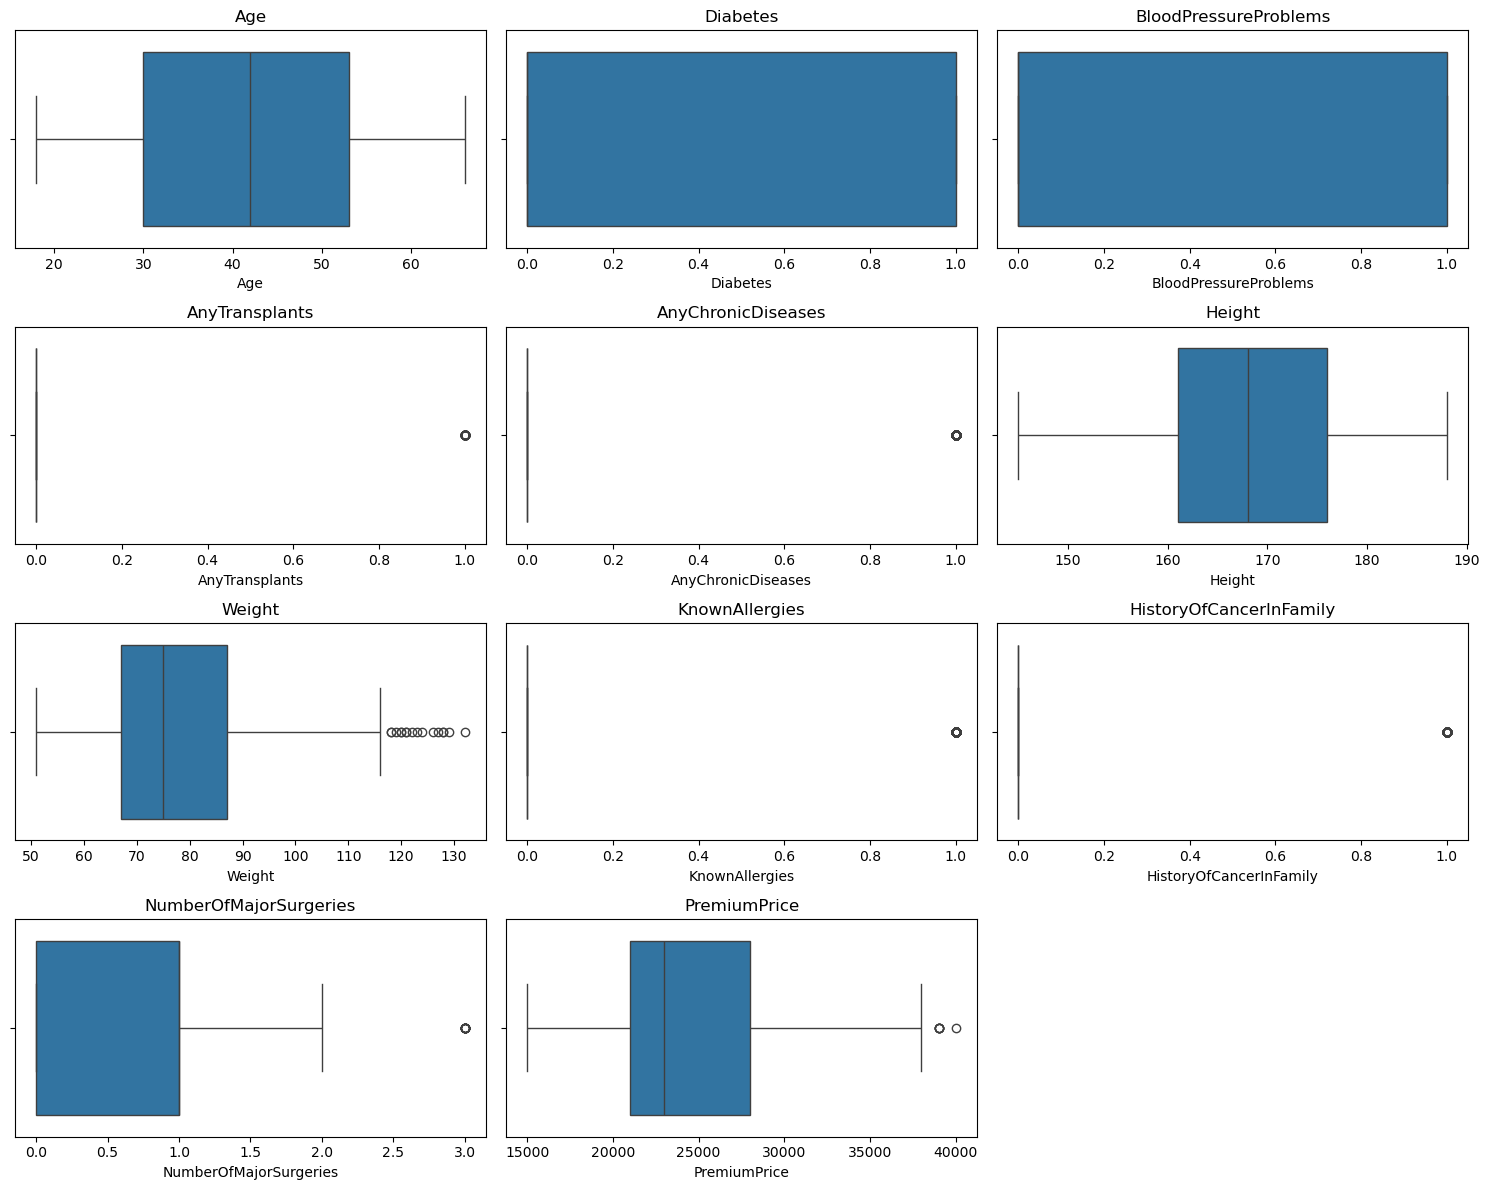

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Verideki tüm sayısal sütunları seçelim
numerical_cols = df.columns 

# Grafik boyutunu ayarlayalım
plt.figure(figsize=(15, 12))

# Her bir sütun için bir boxplot çizelim
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1) # 11 sütun olduğu için 4x3 ideal
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.tight_layout()

plt.show()

In [4]:
# Aykırı değerleri tespit eden fonksiyon
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return outliers

# Her sütun için aykırı değer sayısını yazdıralım
for col in df.columns:
    outliers = detect_outliers(df, col)
    print(f"{col} sütununda {len(outliers)} adet aykırı değer bulundu.")

Age sütununda 0 adet aykırı değer bulundu.
Diabetes sütununda 0 adet aykırı değer bulundu.
BloodPressureProblems sütununda 0 adet aykırı değer bulundu.
AnyTransplants sütununda 55 adet aykırı değer bulundu.
AnyChronicDiseases sütununda 178 adet aykırı değer bulundu.
Height sütununda 0 adet aykırı değer bulundu.
Weight sütununda 16 adet aykırı değer bulundu.
KnownAllergies sütununda 212 adet aykırı değer bulundu.
HistoryOfCancerInFamily sütununda 116 adet aykırı değer bulundu.
NumberOfMajorSurgeries sütununda 16 adet aykırı değer bulundu.
PremiumPrice sütununda 6 adet aykırı değer bulundu.


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Hedef değişken (y) PremiumPrice, diğerleri özellikler (X)
X = df.drop('PremiumPrice', axis=1)
y = df['PremiumPrice']

# Eğitim ve Test verisine ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeli kur ve eğit
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# Tahmin yap
y_pred = reg_model.predict(X_test)

# Performans metriklerini yazdır
print("--- Regresyon Performans Metrikleri ---")
print(f"R2 Skoru (Başarı): {r2_score(y_test, y_pred):.2f}")
print(f"MSE (Hata Payı): {mean_squared_error(y_test, y_pred):.2f}")

--- Regresyon Performans Metrikleri ---
R2 Skoru (Başarı): 0.71
MSE (Hata Payı): 12221661.71


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# 1. Ölçeklendirme (Feature Scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # X'i yeni ölçeğine getiriyoruz

# 2. Eğitim ve Test verisini tekrar ayır
X_train_s, X_test_s, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Random Forest Regressor ile eğit
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_s, y_train)

# 4. Tahmin ve Rapor
y_pred_rf = rf_reg.predict(X_test_s)

print("--- İyileştirilmiş Model (Random Forest + Scaling) ---")
print(f"Yeni R2 Skoru: {r2_score(y_test, y_pred_rf):.2f}")

--- İyileştirilmiş Model (Random Forest + Scaling) ---
Yeni R2 Skoru: 0.87


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Tahminleri ve gerçek değerleri karşılaştıralım
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 1036.72
Root Mean Squared Error (RMSE): 2309.34


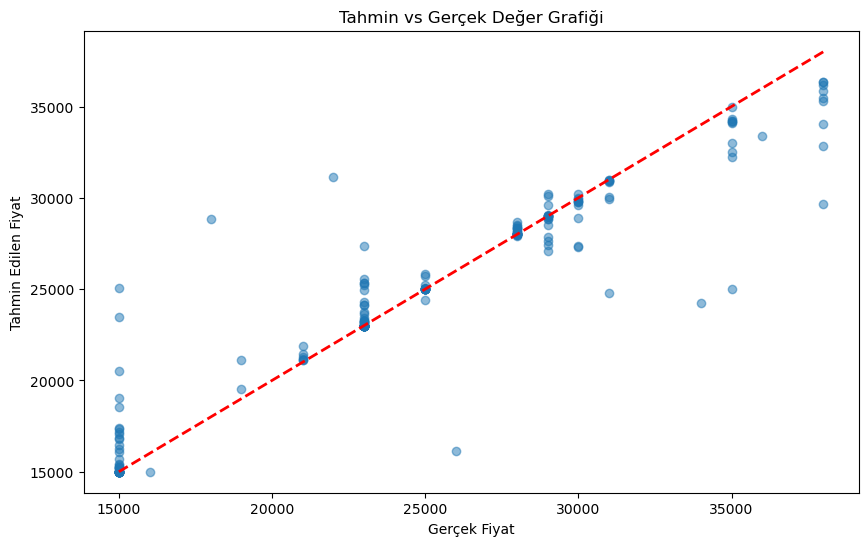

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Gerçek Fiyat")
plt.ylabel("Tahmin Edilen Fiyat")
plt.title("Tahmin vs Gerçek Değer Grafiği")
plt.show()

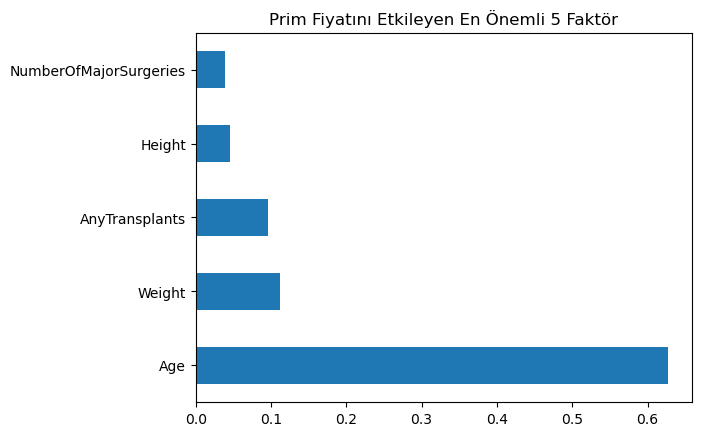

In [9]:
feature_importances = pd.Series(rf_reg.feature_importances_, index=X.columns)
feature_importances.nlargest(5).plot(kind='barh')
plt.title("Prim Fiyatını Etkileyen En Önemli 5 Faktör")
plt.show()

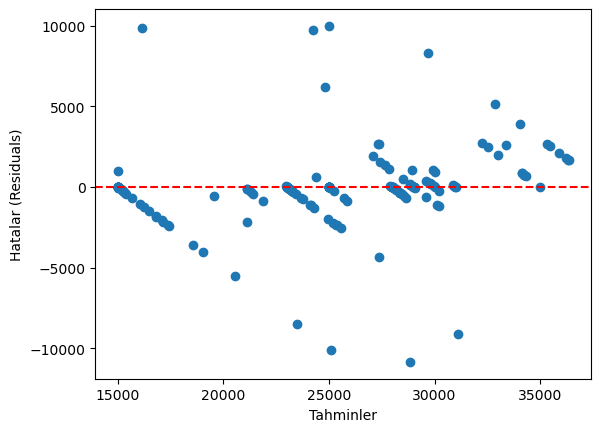

In [11]:
residuals = y_test - y_pred_rf
plt.scatter(y_pred_rf, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Tahminler")
plt.ylabel("Hatalar (Residuals)")
plt.show()